In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from apyori import apriori

grocery_items = set()
with open("Cross and Up Selling Problem/grocery_dataset.txt") as my_file:
    reader = csv.reader(my_file, delimiter=",")
    for i, line in enumerate(reader):
        grocery_items.update(line)

In [2]:
display("---".join(grocery_items))
print(len(grocery_items))

'soups---specialty chocolate---canned fruit---photo/film---other vegetables---abrasive cleaner---ice cream---frozen dessert---kitchen towels---cereals---beef---ketchup---sauces---specialty bar---root vegetables---red/blush wine---soap---bottled water---sugar---cream---cake bar---nut snack---rolls/buns---cookware---domestic eggs---dessert---cocoa drinks---candy---liquor---whipped/sour cream---female sanitary products---meat---cleaner---long life bakery product---coffee---toilet cleaner---pudding powder---canned vegetables---popcorn---artif. sweetener---canned beer---baby food---salty snack---potato products---rum---flour---seasonal products---fish---make up remover---salad dressing---fruit/vegetable juice---flower soil/fertilizer---organic products---dish cleaner---dishes---skin care---decalcifier---herbs---frozen fish---beverages---butter milk---soda---cling film/bags---sausage---napkins---salt---mustard---Instant food products---specialty vegetables---berries---zwieback---vinegar---ho

169


In [3]:
output_list = list()
with open("Cross and Up Selling Problem/grocery_dataset.txt") as my_file:
    reader = csv.reader(my_file, delimiter=",")
    for i, line in enumerate(reader):
        # create an object with each grocery item as key and 0 as value
        row_val = {item: 0 for item in grocery_items}
        # update the value to 1 if the item is present in the list
        row_val.update({item: 1 for item in line})
        output_list.append(row_val)

In [8]:
print(len(output_list), len(output_list[0]))
print(output_list[0])

9835 169
{'soups': 0, 'specialty chocolate': 0, 'canned fruit': 0, 'photo/film': 0, 'other vegetables': 0, 'abrasive cleaner': 0, 'ice cream': 0, 'frozen dessert': 0, 'kitchen towels': 0, 'cereals': 0, 'beef': 0, 'ketchup': 0, 'sauces': 0, 'specialty bar': 0, 'root vegetables': 0, 'red/blush wine': 0, 'soap': 0, 'bottled water': 0, 'sugar': 0, 'cream': 0, 'cake bar': 0, 'nut snack': 0, 'rolls/buns': 0, 'cookware': 0, 'domestic eggs': 0, 'dessert': 0, 'cocoa drinks': 0, 'candy': 0, 'liquor': 0, 'whipped/sour cream': 0, 'female sanitary products': 0, 'meat': 0, 'cleaner': 0, 'long life bakery product': 0, 'coffee': 0, 'toilet cleaner': 0, 'pudding powder': 0, 'canned vegetables': 0, 'popcorn': 0, 'artif. sweetener': 0, 'canned beer': 0, 'baby food': 0, 'salty snack': 0, 'potato products': 0, 'rum': 0, 'flour': 0, 'seasonal products': 0, 'fish': 0, 'make up remover': 0, 'salad dressing': 0, 'fruit/vegetable juice': 0, 'flower soil/fertilizer': 0, 'organic products': 0, 'dish cleaner': 0, 

In [9]:
grocery_df = pd.DataFrame(output_list)

In [15]:
print(grocery_df.shape)
display(grocery_df.head())

(9835, 169)


,soups,specialty chocolate,canned fruit,photo/film,other vegetables,abrasive cleaner,ice cream,frozen dessert,kitchen towels,cereals,...,spread cheese,chicken,hard cheese,curd cheese,ham,light bulbs,sound storage medium,preservation products,grapes,processed cheese
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# View top sold items
total_item_count = sum(grocery_df.sum())
print(total_item_count)
item_summary_df = grocery_df.sum().sort_values(ascending = False).reset_index().head(n=20)
item_summary_df.rename(columns={item_summary_df.columns[0]:'item_name',item_summary_df.columns[1]:'item_count'}, inplace=True)
item_summary_df.head()

43367


,item_name,item_count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372


<BarContainer object of 20 artists>

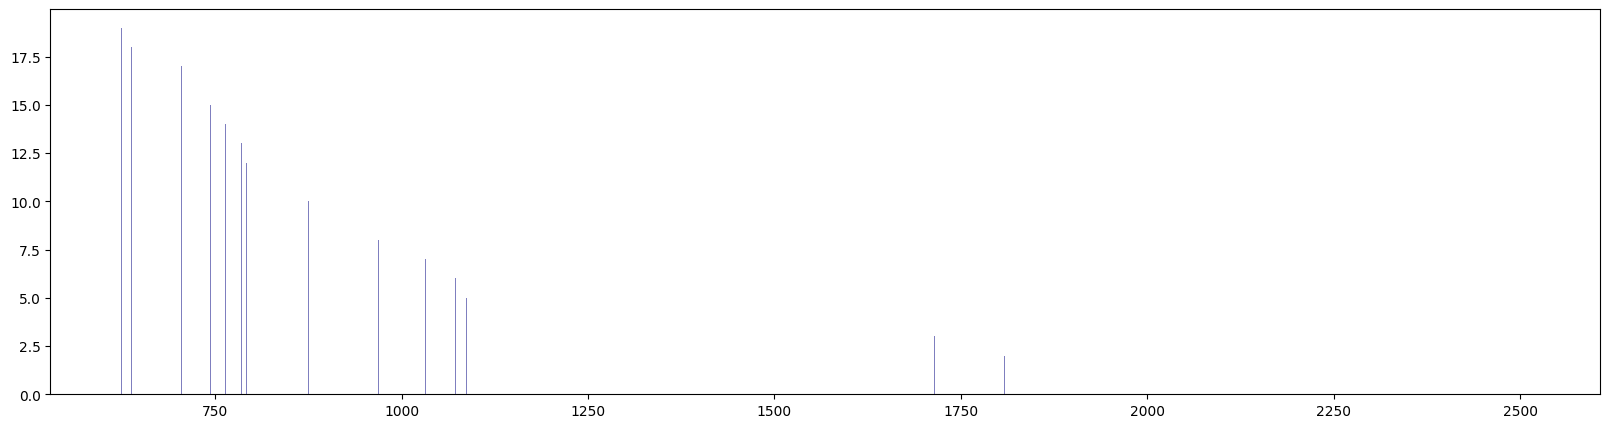

In [37]:
# Visualize top sold items
objects = list(item_summary_df["item_name"].head(n=20))
y_pos = np.arange(len(objects))
performance = list(item_summary_df["item_count"].head(n=20))

plt.figure(figsize=(20, 5))
plt.bar(performance, y_pos, align="center", alpha=0.5, color="navy")
# plt.yticks(performance, objects, rotation="horizontal", fontsize=28)
# display(performance)